In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
qs = [1.0, 0.8, 0.6, 0.4, 0.2, 0.0]
dfs = []
for q in qs:
    eval_df = pd.read_csv(f'~/data/7_Simulation/results/q{int(q*100)}/snpnet.eval.tsv.gz', sep='\t', compression='gzip')
    eval_df['true_percentage'] = int(q*100)
    dfs.append(eval_df)

In [3]:
df = pd.concat(dfs)

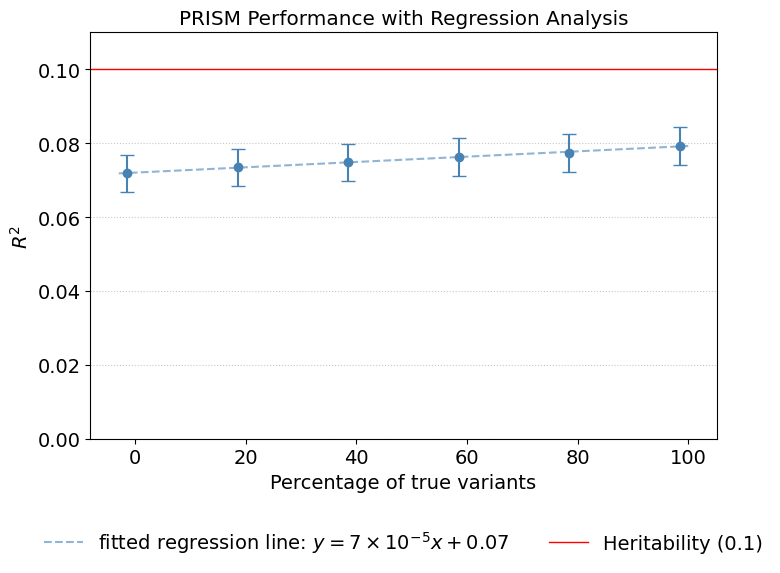

In [4]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})


# 1. Calculate the "error" 
df['low'] = df['eval'] - df['l_eval']
df['high'] = df['u_eval'] - df['eval']

# Filtering data
pgs = df[(df['split'] == 'test') & (df['model'] == 'PGS')]
full = df[(df['split'] == 'test') & (df['model'] == 'full')]

plt.figure(figsize=(8, 6))

# Define the jitter and heritability
jitter = 1.5 
heritability = 0.1

# Define x-range for the lines to ensure they span the whole plot
x_min, x_max = df['true_percentage'].min(), df['true_percentage'].max()
x_fit = np.linspace(x_min - jitter, x_max + jitter, 100)

# --- PGS Regression & Plot ---
m_pgs, b_pgs = np.polyfit(pgs['true_percentage'], pgs['eval'], 1)
# Create label with equation
pgs_label = f'$y = {m_pgs:.5f}x + {b_pgs:.5f}$)'

plt.errorbar(pgs['true_percentage'] - jitter, pgs['eval'], 
             yerr=[pgs['low'], pgs['high']], 
             fmt='o', capsize=5, color='steelblue')
# Note: We apply the jitter to the x-values of the line plot so it aligns with the points
plt.plot(x_fit - jitter, m_pgs * x_fit + b_pgs, color='steelblue', linestyle='--', alpha=0.6, label = 'fitted regression line: ' +r'$y = 7 \times 10^{-5}x + 0.07$')


# --- Reference & Formatting ---
plt.axhline(y=heritability, color='red', linestyle='-', label=f'Heritability ({heritability})', linewidth=1)

plt.ylabel('$R^{2}$')
plt.xlabel('Percentage of true variants')
plt.title('PRISM Performance with Regression Analysis')

# Move legend outside if it gets too crowded
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False
)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.ylim(0, 0.11) # Adjusted to show heritability clearly
plt.tight_layout()
#plt.savefig('simulation.pdf', bbox_inches='tight')
plt.show()

# --- Quantitative Conclusion ---
rel_imp_full = (m_pgs / heritability) * 100
